## EMI Forecasting

In [1]:
pip install statsmodels pmdarima

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import ParameterGrid
from pmdarima import auto_arima

In [3]:
df = pd.read_csv('emi_monthly_prices.csv')
df

,month,emi_wogs_gte_4_lbs_fresh_80,emi_wog_2_5_4_0_lbs_fresh_70,emi_wog_marinated_fresh_87,emi_8_9_piece_lt_2_5_lbs_fresh_100,emi_8_9_pc_marinated_fresh_125,emi_front_halves_all_fresh_133,emi_breast_whole_split_fresh_220,emi_breast_whole_split_small_fresh_222,emi_bs_breast_unsized_medium_fresh_270,...,emi_whole_wings_medium_fresh_351,emi_wings_drmts_midjnt_medium_fresh_413,emi_wings_drmts_midjnt_small_fresh_414,emi_bs_breast_unsized_all_frozen_273,emi_wing_tips_frozen_380,emi_wings_drmts_midjnt_frozen_410,emi_leg_quarters_frozen_500,emi_leg_quarters_jumbo_frozen_501,emi_bs_thighs_frozen_590,emi_msc_all_frozen_820
0,1/1/01,52.00,55.60,63.60,65.70,67.1,70.00,62.50,62.50,126.3,...,0.0,0.0,0.0,125.00,17.30,120.0,20.10,20.10,80.00,17.50
1,2/1/01,52.30,57.00,63.20,66.10,67.9,71.00,73.60,73.60,130.2,...,0.0,0.0,0.0,125.00,17.70,121.0,20.80,20.80,88.20,16.80
2,3/1/01,55.70,58.10,62.70,68.30,68.2,71.50,72.40,72.40,130.3,...,0.0,0.0,0.0,125.00,19.90,118.0,22.10,22.10,90.00,17.60
3,4/1/01,54.20,58.30,63.40,68.80,68.2,71.50,71.50,71.50,125.6,...,0.0,0.0,0.0,126.00,19.50,115.0,25.70,25.70,90.15,18.10
4,5/1/01,53.14,57.85,64.54,68.28,68.6,72.49,80.67,76.39,126.6,...,0.0,0.0,0.0,127.43,14.61,98.0,29.01,29.01,108.07,17.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Prepping Data

In [4]:
# Rename column name 'month' to 'date'
df = df.rename(columns={'month':'date'})

In [5]:
# understand the NA situation in the dataset
df.isna().sum()

date                                        22
emi_wogs_gte_4_lbs_fresh_80                 22
emi_wog_2_5_4_0_lbs_fresh_70                22
emi_wog_marinated_fresh_87                  22
emi_8_9_piece_lt_2_5_lbs_fresh_100          22
emi_8_9_pc_marinated_fresh_125              22
emi_front_halves_all_fresh_133              22
emi_breast_whole_split_fresh_220            22
emi_breast_whole_split_small_fresh_222      22
emi_bs_breast_unsized_medium_fresh_270      22
emi_bs_breast_unsized_jumbo_fresh_271       22
emi_bs_breast_unsized_small_fresh_272       22
emi_breast_trim_lte_5_fat_fresh_312         22
emi_breast_trim_6_15_fat_fresh_315          22
emi_tenders_medium_fresh_320                22
emi_tenders_jumbo_fresh_321                 22
emi_tenders_small_fresh_340                 22
emi_whole_wings_fresh_350                   74
emi_whole_wings_jumbo_fresh_370             22
emi_wings_drmts_midjnt_jumbo_fresh_411      22
emi_wings_drmts_midjnt_fresh_412            74
emi_leg_quart

In [6]:
# Drop NA rows from 'date'
df  = df.dropna(subset = 'date')
df.isna().sum()

date                                         0
emi_wogs_gte_4_lbs_fresh_80                  0
emi_wog_2_5_4_0_lbs_fresh_70                 0
emi_wog_marinated_fresh_87                   0
emi_8_9_piece_lt_2_5_lbs_fresh_100           0
emi_8_9_pc_marinated_fresh_125               0
emi_front_halves_all_fresh_133               0
emi_breast_whole_split_fresh_220             0
emi_breast_whole_split_small_fresh_222       0
emi_bs_breast_unsized_medium_fresh_270       0
emi_bs_breast_unsized_jumbo_fresh_271        0
emi_bs_breast_unsized_small_fresh_272        0
emi_breast_trim_lte_5_fat_fresh_312          0
emi_breast_trim_6_15_fat_fresh_315           0
emi_tenders_medium_fresh_320                 0
emi_tenders_jumbo_fresh_321                  0
emi_tenders_small_fresh_340                  0
emi_whole_wings_fresh_350                   52
emi_whole_wings_jumbo_fresh_370              0
emi_wings_drmts_midjnt_jumbo_fresh_411       0
emi_wings_drmts_midjnt_fresh_412            52
emi_leg_quart

In [7]:
# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'])
df['date']

C:\Users\LUJEN\AppData\Local\Temp\ipykernel_3384\3955120403.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


0     2001-01-01
1     2001-02-01
2     2001-03-01
3     2001-04-01
4     2001-05-01
         ...    
297   2025-10-01
298   2025-11-01
299   2025-12-01
300   2026-01-01
301   2026-02-01
Name: date, Length: 302, dtype: datetime64[ns]

In [8]:
# set column 'date' as index
df.set_index('date', inplace=True)
df

,emi_wogs_gte_4_lbs_fresh_80,emi_wog_2_5_4_0_lbs_fresh_70,emi_wog_marinated_fresh_87,emi_8_9_piece_lt_2_5_lbs_fresh_100,emi_8_9_pc_marinated_fresh_125,emi_front_halves_all_fresh_133,emi_breast_whole_split_fresh_220,emi_breast_whole_split_small_fresh_222,emi_bs_breast_unsized_medium_fresh_270,emi_bs_breast_unsized_jumbo_fresh_271,...,emi_whole_wings_medium_fresh_351,emi_wings_drmts_midjnt_medium_fresh_413,emi_wings_drmts_midjnt_small_fresh_414,emi_bs_breast_unsized_all_frozen_273,emi_wing_tips_frozen_380,emi_wings_drmts_midjnt_frozen_410,emi_leg_quarters_frozen_500,emi_leg_quarters_jumbo_frozen_501,emi_bs_thighs_frozen_590,emi_msc_all_frozen_820
date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,52.00,55.60,63.60,65.70,67.10,70.00,62.50,62.50,126.30,126.30,...,0.00,0.00,0.00,125.00,17.30,120.00,20.10,20.10,80.00,17.50
2001-02-01,52.30,57.00,63.20,66.10,67.90,71.00,73.60,73.60,130.20,130.20,...,0.00,0.00,0.00,125.00,17.70,121.00,20.80,20.80,88.20,16.80
2001-03-01,55.70,58.10,62.70,68.30,68.20,71.50,72.40,72.40,130.30,130.30,...,0.00,0.00,0.00,125.00,19.90,118.00,22.10,22.10,90.00,17.60
2001-04-01,54.20,58.30,63.40,68.80,68.20,71.50,71.50,71.50,125.60,125.60,...,0.00,0.00,0.00,126.00,19.50,115.00,25.70,25.70,90.15,18.10
2001-05-01,53.14,57.85,64.54,68.28,68.60,72.49,80.67,76.39,126.60,126.60,...,0.00,0.00,0.00,127.43,14.61,98.00,29.01,29.01,108.07,17.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,68.55,90.05,104.29,125.37,123.42,89.63,101.31,105.27,117.60,117.19,...,108.73,139.66,138.52,119.51,0.00,151.47,52.25,54.26,150.05,29.33
2025-11-01,76.21,89.63,104.31,124.81,123.21,73.94,96.28,95.73,121.92,115.88,...,106.84,127.77,131.33,118.93,0.00,157.05,52.06,55.74,123.87,28.56
2025-12-01,85.06,98.68,104.10,125.48,122.91,75.42,88.54,94.76,124.56,116.84,...,108.50,125.19,130.77,121.57,0.00,168.68,52.11,56.06,121.78,27.94


In [9]:
# Setting frequency as monthly start (MS)
df = df.asfreq('MS')

Price unit is cents per lbs

In [10]:
# Select the columns for the three drivers
drivers = df[["emi_bs_breast_unsized_jumbo_fresh_271", "emi_leg_quarters_fresh_500", "emi_whole_wings_jumbo_fresh_370"]]
# Get drivers from year 2020
drivers.loc['2022-01-01': '2022-12-31']

,emi_bs_breast_unsized_jumbo_fresh_271,emi_leg_quarters_fresh_500,emi_whole_wings_jumbo_fresh_370
date,,,
2022-01-01,213.08,37.05,270.13
2022-02-01,243.85,36.99,256.67
2022-03-01,255.97,38.85,217.09
2022-04-01,275.79,44.74,182.95
2022-05-01,315.53,51.84,171.33
2022-06-01,292.50,61.10,173.25
2022-07-01,256.50,59.63,149.41
2022-08-01,210.96,56.44,121.71
2022-09-01,183.01,44.03,123.62


In [11]:
# Checking to see if there are any NA values in the three drivers
drivers.isna().sum()

emi_bs_breast_unsized_jumbo_fresh_271    0
emi_leg_quarters_fresh_500               0
emi_whole_wings_jumbo_fresh_370          0
dtype: int64

In [12]:
drivers.rename(columns = {'emi_bs_breast_unsized_jumbo_fresh_271': 'breast', 'emi_leg_quarters_fresh_500': 'leg_quarters', 'emi_whole_wings_jumbo_fresh_370': 'wings'}, inplace=True)

C:\Users\LUJEN\AppData\Local\Temp\ipykernel_3384\4008505140.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drivers.rename(columns = {'emi_bs_breast_unsized_jumbo_fresh_271': 'breast', 'emi_leg_quarters_fresh_500': 'leg_quarters', 'emi_whole_wings_jumbo_fresh_370': 'wings'}, inplace=True)


## Exploratory Data Analysis
Target Driver: Chicken Breast OR emi_bs_breast_unsized_jumbo_fresh_271    

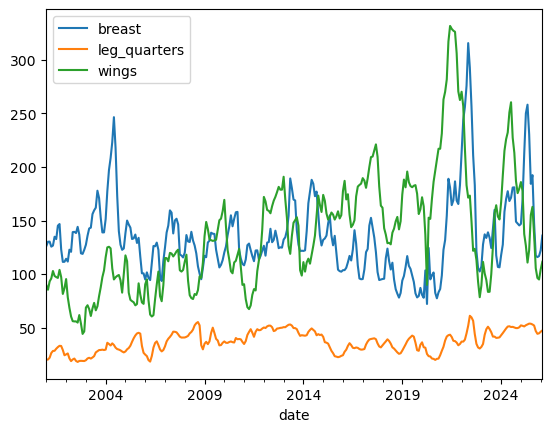

In [13]:
# Plot the three drivers
drivers.plot()
plt.show()

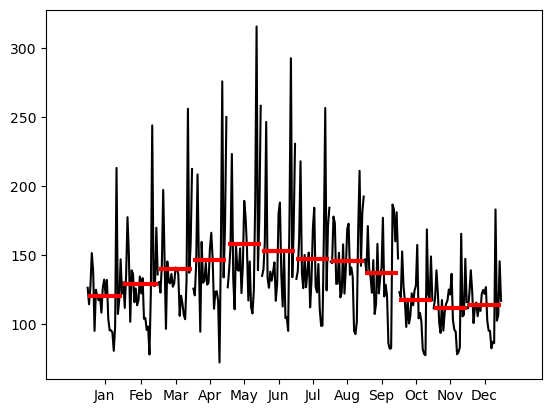

In [14]:
# Plotting seasonality for Chicken Breast
month_plot(drivers['breast'])
plt.show()

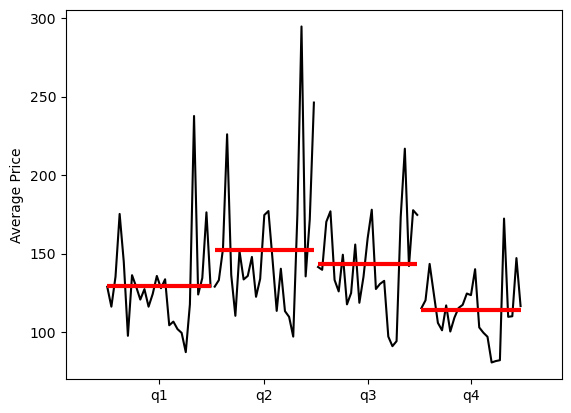

In [15]:
# Plotting the quarterly seasonality for Chicken Breast
quarter_plot(drivers['breast'].resample('QS').mean(),
             ylabel = "Average Price")
plt.show()

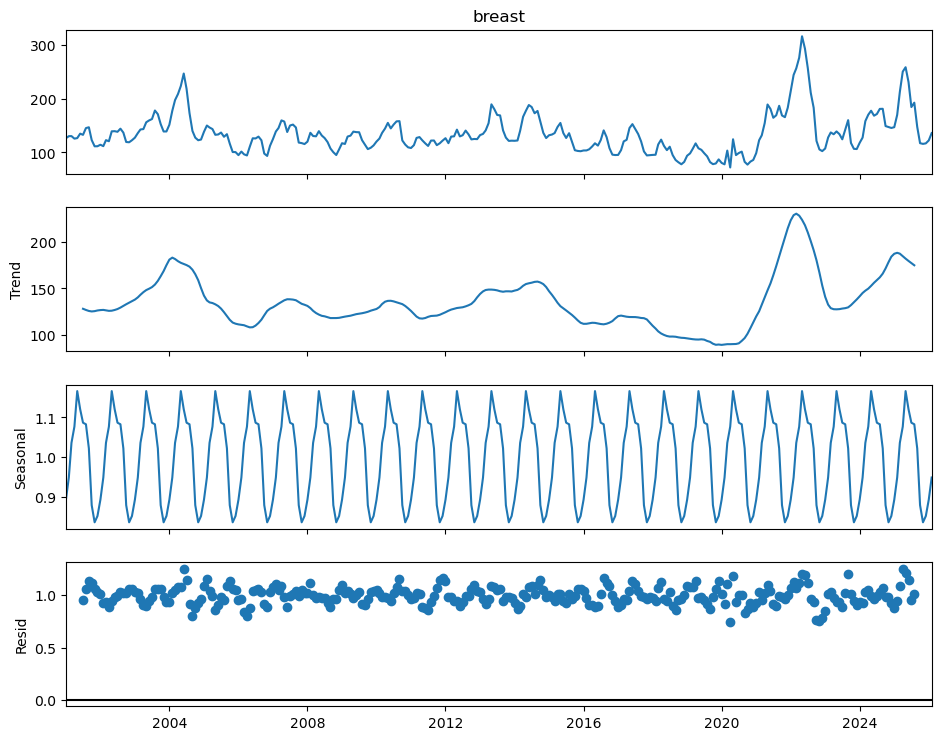

In [16]:
# Seasonal Decomposition Plot for chicken breast 
decomposition = seasonal_decompose(drivers['breast'], 
                                   model = 'mul',
                                   period = 12)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

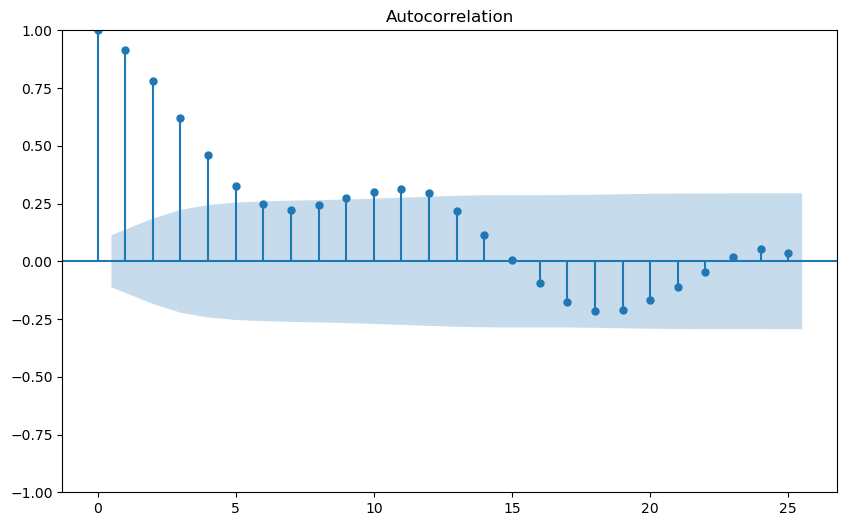

In [17]:
# Plotting the ACF graph 
fig, ax = plt.subplots(figsize = (10, 6))
plot_acf(drivers['breast'], ax = ax)
plt.show()
# Observation: There is a significant spike at lag 12, which indicates a strong seasonal pattern in the data. 
# This suggests that the price of chicken breast may be influenced by seasonal factors, such as holidays or weather conditions.
# Additionally, lags 1-5 is above the shaded area, which indicates that there is some autocorrelation in the data, meaning that the price of chicken breast at a given time may be influenced by its price at previous time periods.

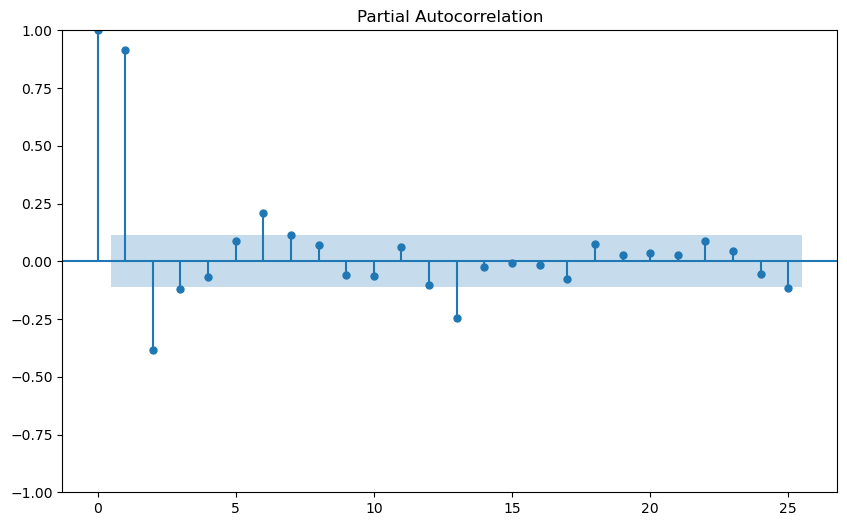

In [18]:
# Plotting the PACF graph 
fig, ax = plt.subplots(figsize = (10, 6))
plot_pacf(drivers['breast'], ax = ax)
plt.show()
# Observation: At lag 1 - 3, there is a strong correlation between these lags compared to current price of chicken breast
# Which suggests that the price of chicken breast at a given time may be influenced by its price at the previous 3 time periods.

## Functions

In [19]:
# Function to assess model and visualize output
def model_assessment(train, test, predictions, chart_title):
  # Plot train, test, and predictions
  plt.figure(figsize = (10,4))
  plt.plot(train)
  plt.plot(test)
  plt.plot(predictions)
  plt.legend(['Train', 'Test', 'Forecast'])
  plt.title(f"Train, Test, and Predictions with {chart_title}")
  plt.show()

  # Calculate MAE
  mae = mean_absolute_error(test, predictions)
  # Calculate RMSE
  mse = mean_squared_error(test, predictions) # Calculate MSE
  rmse = mse**0.5 # Take the square root of MSE to get RMSE
  # Calculate MAPE
  mape = mean_absolute_percentage_error(test, predictions)

  print(f"The MAE is{mae: .2f}")
  print(f"The RMSE is{rmse: .2f}")
  print(f"The MAPE is {100 * mape: .2f}%")

In [20]:
# Function to plot the future
def plot_future(y, forecast, title):
  # Plot train and forecast
  plt.figure(figsize = (10,4))
  plt.plot(y)
  plt.plot(forecast)
  plt.legend(['Train', 'Forecast'])
  plt.title(f"Train and Forecast with {title}")
  plt.show()

## Exponential Smoothing

In [21]:
# Train test split 
period = 12
train = drivers.iloc[:-period, 0]
test = drivers.iloc[-period:, 0]
test

date
2025-03-01    212.29
2025-04-01    249.98
2025-05-01    258.07
2025-06-01    230.48
2025-07-01    184.23
2025-08-01    192.32
2025-09-01    147.50
2025-10-01    117.19
2025-11-01    115.88
2025-12-01    116.84
2026-01-01    122.24
2026-02-01    135.91
Freq: MS, Name: breast, dtype: float64

In [22]:
# Triple Exponential Smoothing (Holt-Winters) Model
model_triple = ExponentialSmoothing(train, 
                                    trend = 'add', 
                                    seasonal = 'mul', 
                                    seasonal_periods = 12).fit()

In [23]:
predictions_triple = model_triple.forecast(len(test))
predictions_triple

2025-03-01    182.511752
2025-04-01    190.939372
2025-05-01    207.050085
2025-06-01    201.421735
2025-07-01    193.967552
2025-08-01    189.255624
2025-09-01    180.202199
2025-10-01    153.815260
2025-11-01    146.633230
2025-12-01    149.930928
2026-01-01    159.254652
2026-02-01    171.669336
Freq: MS, dtype: float64

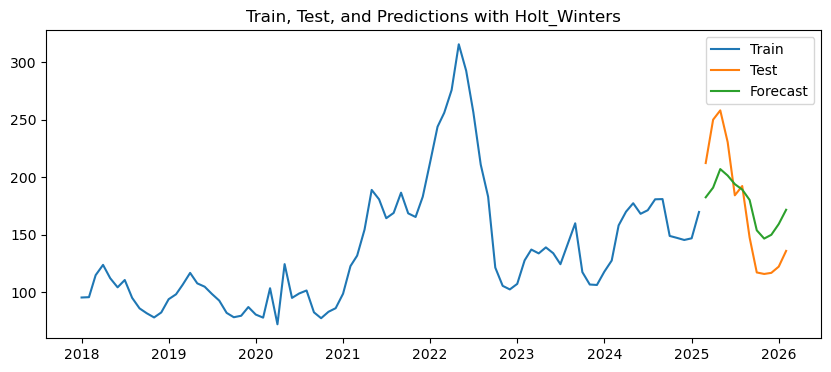

The MAE is 32.30
The RMSE is 35.38
The MAPE is  20.15%


In [24]:
# Assess model 
model_assessment(train['2018':], test, predictions_triple, 'Holt_Winters')

## Stationary

In [25]:
from statsmodels.tsa.stattools import adfuller # augmented dickey-fuller
# Perform ADF test
result = adfuller(drivers.breast)
print('p-value: %f' % result[1])

# Interpreting the results:
if result[1] < 0.05:
  print("Evidence suggests that the time series is stationary.")
else:
  print("Evidence suggests that the time series is not stationary.")

p-value: 0.000589
Evidence suggests that the time series is stationary.


## Applying the SARIMA model

In [26]:
# Train test split
period = 12
train = drivers.iloc[:-period, 0]
test = drivers.iloc[-period:, 0]
test

date
2025-03-01    212.29
2025-04-01    249.98
2025-05-01    258.07
2025-06-01    230.48
2025-07-01    184.23
2025-08-01    192.32
2025-09-01    147.50
2025-10-01    117.19
2025-11-01    115.88
2025-12-01    116.84
2026-01-01    122.24
2026-02-01    135.91
Freq: MS, Name: breast, dtype: float64

In [27]:
# Find the best SARIMA parameters bsed on AIC
model_sarima = auto_arima(train,
                          seasonal = True, 
                          m = 12, 
                          stepwise = True, 
                          trace = True)
print(model_sarima.summary())
model_sarima.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.89 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2887.768, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2322.259, Time=0.29 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2592.011, Time=0.19 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3681.931, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=2356.852, Time=0.04 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=2309.377, Time=1.01 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.23 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.52 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=2867.490, Time=2.19 sec
 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=2288.535, Time=2.16 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=2297.015, Time=0.61 sec
 ARIMA(2,0,0)(2,0,1)[12] intercept   : AIC=2270.693, Time=1.67 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=2265.305, Time=0.60 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  290
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 12)   Log Likelihood               -1126.652
Date:                              Wed, 03 Jun 2026   AIC                           2265.305
Time:                                      15:50:36   BIC                           2287.324
Sample:                                  01-01-2001   HQIC                          2274.127
                                       - 02-01-2025                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1823      0.259      0.705      0.481      -0.325       0.689
ar.L1          1.1410      0.036     31.673      0.000       1.070       1.212
ar.L2         -0.2206      0.035     -6.285      0.000      -0.289      -0.152
ar.S.L12       0.9831      0.021     47.408      0.000       0.942       1.024
ma.S.L12      -0.8798      0.065    -13.466      0.000      -1.008      -0.752
sigma2       132.3433      8.935     14.812      0.000     114.831     149.855
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                83.99
Prob(Q):                              0.81   Prob(JB):                         0.00
Heteroskedasticity (H):               2.30   Skew:                            -0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [28]:
# Make predictions on the test set 
predictions_sarima = model_sarima.predict(n_periods = len(test))
predictions_sarima

2025-03-01    181.144399
2025-04-01    183.333705
2025-05-01    192.543208
2025-06-01    182.050343
2025-07-01    173.754979
2025-08-01    169.518979
2025-09-01    162.229786
2025-10-01    139.978867
2025-11-01    133.329716
2025-12-01    133.318508
2026-01-01    137.651844
2026-02-01    146.157806
Freq: MS, dtype: float64

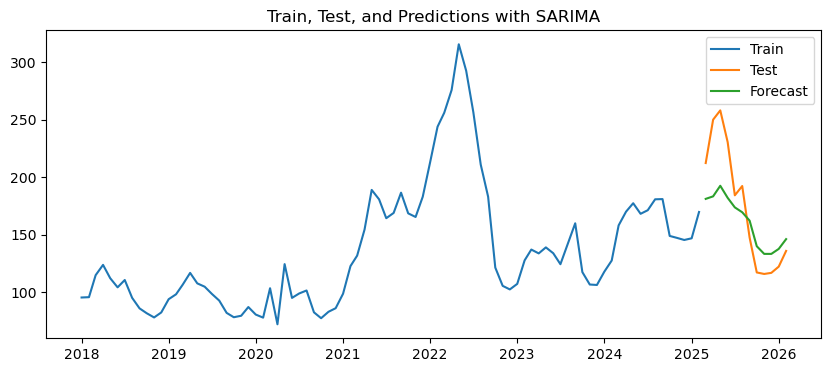

The MAE is 28.51
The RMSE is 34.56
The MAPE is  15.33%


In [29]:
# Compare the test set to the predictions
model_assessment(train['2018':], test, predictions_sarima, 'SARIMA')

Observation: Leg quarters and wings are not drivers of breast prices.
To find better exogenous variables, we need to look at: 

**Cost Drivers**
- Feed costs: corn & soy prices
- Energy/fuel prices: transportation and processing
- Labor index - wage inflations

**Demand Drivers**
- Unemployment rate: affects consumer purchasing power 
- Consumer Confidence Index: sentiment/spending
- Protein prices: beef & pork competition

**Other factors**
- Avian flu outbreaks (H5N1)
- Seasonal holidays: Thanksgiving, Christmas, etc.


In [30]:
## Find Best Internal Predictors via Correlation
# Examine ALL columns in your dataset to find which correlate with breast
correlation_with_breast = df.corrwith(df['emi_bs_breast_unsized_jumbo_fresh_271']).sort_values(ascending=False)
print("\n=== Correlation with Breast Price ===")
print(correlation_with_breast)


=== Correlation with Breast Price ===
emi_bs_breast_unsized_jumbo_fresh_271      1.000000
emi_bs_breast_unsized_medium_fresh_270     0.977670
emi_bs_breast_unsized_all_frozen_273       0.962328
emi_breast_trim_lte_5_fat_fresh_312        0.810182
emi_breast_trim_6_15_fat_fresh_315         0.789117
emi_tenders_jumbo_fresh_321                0.774947
emi_bs_breast_unsized_small_fresh_272      0.761630
emi_tenders_medium_fresh_320               0.732798
emi_front_halves_all_fresh_133             0.715638
emi_breast_whole_split_fresh_220           0.690565
emi_tenders_small_fresh_340                0.652714
emi_bs_thighs_fresh_590                    0.613739
emi_bs_thighs_frozen_590                   0.583812
emi_breast_whole_split_small_fresh_222     0.578677
emi_bs_legmeat_fresh_560                   0.527723
emi_thighs_fresh_570                       0.480349
emi_whole_legs_jumbo_fresh_530             0.472001
emi_wog_2_5_4_0_lbs_fresh_70               0.467082
emi_whole_legs_fresh_510 

## Training on Exogenous Factors with Data from Federal Reserve (FRED)

In [31]:
## Download Economic Data from FRED (Federal Reserve)

# First install if needed
import subprocess
subprocess.run(['pip', 'install', 'pandas-datareader', '--quiet'], check=False)

import pandas_datareader as pdr
from datetime import datetime

# Define your date range (match your chicken data)
start_date = df.index.min() # 2001-01-01
end_date = df.index.max() #2026-02-01

print(f"Downloading data from {start_date.date()} to {end_date.date()}...\n")

# Dictionary of FRED indicators relevant to poultry prices
fred_indicators = {
    'PMAIZMTUSDM': 'Corn Prices (Global Price, USD/Metric Ton Monthly)',
    'PSOYBUSDM': 'Soybean Prices (USD/Metric Ton Monthly)',
    'MHOILNYH': 'Heating Oil Prices (Monthly, $/gallon)', 
    'UNRATE': 'Unemployment Rate',
    'UMCSENT': 'Consumer Sentiment Index',
    'CPIAUCSL': 'Consumer Price Index',
    'PBEEFUSDM': 'Beef Price (US cents/lb Monthly)',
}

# Download data
economic_data = {}
for code, label in fred_indicators.items():
    try:
        data = pdr.get_data_fred(code, start=start_date, end=end_date)
        economic_data[label] = data
        print(f"✓ Downloaded: {label} ({code})")
    except Exception as e:
        print(f"✗ Failed: {label} ({code}) - {str(e)[:50]}")

# Combine into one DataFrame
exog_external = pd.concat([v for v in economic_data.values()], axis=1)
exog_external.columns = economic_data.keys()
print(f"\nExternal data shape: {exog_external.shape}")
exog_external



✓ Downloaded: Corn Prices (Global Price, USD/Metric Ton Monthly) (PMAIZMTUSDM)
✓ Downloaded: Soybean Prices (USD/Metric Ton Monthly) (PSOYBUSDM)
✓ Downloaded: Heating Oil Prices (Monthly, $/gallon) (MHOILNYH)
✓ Downloaded: Unemployment Rate (UNRATE)
✓ Downloaded: Consumer Sentiment Index (UMCSENT)
✓ Downloaded: Consumer Price Index (CPIAUCSL)
✓ Downloaded: Beef Price (US cents/lb Monthly) (PBEEFUSDM)

External data shape: (302, 7)


,"Corn Prices (Global Price, USD/Metric Ton Monthly)",Soybean Prices (USD/Metric Ton Monthly),"Heating Oil Prices (Monthly, $/gallon)",Unemployment Rate,Consumer Sentiment Index,Consumer Price Index,Beef Price (US cents/lb Monthly)
DATE,,,,,,,
2001-01-01,94.297233,175.422758,0.845,4.2,94.7,175.600,NaN
2001-02-01,92.377515,167.453172,0.785,4.2,90.6,176.000,NaN
2001-03-01,91.012154,164.375579,0.741,4.3,91.5,176.100,NaN
2001-04-01,87.545067,158.610836,0.782,4.4,88.4,176.400,NaN
2001-05-01,85.077523,163.870303,0.772,4.3,92.0,177.300,NaN
...,...,...,...,...,...,...,...
2025-10-01,198.017644,371.574143,2.190,NaN,53.6,NaN,314.000000
2025-11-01,201.657888,410.169359,2.376,4.5,51.0,325.063,325.500000
2025-12-01,205.315080,391.549884,2.112,4.4,52.9,326.031,338.652174


In [32]:
# Resample FRED data to monthly (first of month) to match your chicken data
exog_external_monthly = exog_external.resample('MS').first()

# Fill NaN values (forward fill then backward fill)
exog_external_clean = exog_external_monthly.fillna(method='ffill').fillna(method='bfill')

# Check correlation with breast prices
print("Correlation of External Variables with Breast Price:")
correlation_with_breast_ext = exog_external_clean.corrwith(drivers['breast']).sort_values(ascending=False)
print(correlation_with_breast_ext)
print("\n" + "="*60)

# Select top 3-4 correlated variables
# Select variables with correlation > 0.15 (or 0.2)
#top_exog_cols = correlation_with_breast_ext[correlation_with_breast_ext.abs() > 0.3].index.tolist()
#if len(top_exog_cols) == 0:
#    print("No strong correlations found. Using all available variables.")
#    exog_best = exog_external_clean
#else:
#    print(f"\nSelected variables (correlation > 0.3): {top_exog_cols}")
 #   exog_best = exog_external_clean[top_exog_cols]

exog_best = exog_external_clean.copy()

print("\nUsing ALL external variables:")
print(exog_best.columns.tolist())    

# Standardize (important for SARIMAX)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
exog_scaled = scaler.fit_transform(exog_best)
exog_scaled = pd.DataFrame(exog_scaled, index=exog_best.index, columns=exog_best.columns)

# Split into train/test (align with train/test split of target variable)
exog_train_new = exog_scaled.iloc[:len(train)]
exog_test_new = exog_scaled.iloc[len(train):]

print(f"\nExogenous variables shape:")
print(f"  Train: {exog_train_new.shape}")
print(f"  Test: {exog_test_new.shape}")


Correlation of External Variables with Breast Price:
Beef Price (US cents/lb Monthly)                      0.372145
Soybean Prices (USD/Metric Ton Monthly)               0.278704
Corn Prices (Global Price, USD/Metric Ton Monthly)    0.249402
Heating Oil Prices (Monthly, $/gallon)                0.231553
Consumer Price Index                                  0.192049
Unemployment Rate                                    -0.121361
Consumer Sentiment Index                             -0.306968
dtype: float64


Using ALL external variables:
['Corn Prices (Global Price, USD/Metric Ton Monthly)', 'Soybean Prices (USD/Metric Ton Monthly)', 'Heating Oil Prices (Monthly, $/gallon)', 'Unemployment Rate', 'Consumer Sentiment Index', 'Consumer Price Index', 'Beef Price (US cents/lb Monthly)']

Exogenous variables shape:
  Train: (290, 7)
  Test: (12, 7)


C:\Users\LUJEN\AppData\Local\Temp\ipykernel_3384\3726016429.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  exog_external_clean = exog_external_monthly.fillna(method='ffill').fillna(method='bfill')


### Why scale? 
Because the value ranges for each external variables are different. If we don't scale, the model will give heavier weighting towards variables with bigger ranges and ignore the impact of variables with smaller ranges. 

Formula: Scaled Value = (Original Value - Mean) / Standard Deviation

In [33]:
# Find the best SARIMAX parameters based on AIC with the new exogenous variables
model_sarimax_improved = auto_arima(train,
                                    exogenous=exog_train_new, 
                                    seasonal=True,
                                    m=12,   
                                    stepwise=True,
                                    trace=True)
print(model_sarimax_improved.summary())
model_sarimax_improved.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.97 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2887.768, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2322.259, Time=0.78 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2592.011, Time=0.26 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3681.931, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=2356.852, Time=0.07 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=2309.377, Time=2.06 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.82 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.72 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=2867.490, Time=2.10 sec
 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=2288.535, Time=1.98 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=2297.015, Time=0.49 sec
 ARIMA(2,0,0)(2,0,1)[12] intercept   : AIC=2270.693, Time=1.52 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=2265.305, Time=0.61 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  290
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 12)   Log Likelihood               -1126.652
Date:                              Wed, 03 Jun 2026   AIC                           2265.305
Time:                                      15:51:46   BIC                           2287.324
Sample:                                  01-01-2001   HQIC                          2274.127
                                       - 02-01-2025                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1823      0.259      0.705      0.481      -0.325       0.689
ar.L1          1.1410      0.036     31.673      0.000       1.070       1.212
ar.L2         -0.2206      0.035     -6.285      0.000      -0.289      -0.152
ar.S.L12       0.9831      0.021     47.408      0.000       0.942       1.024
ma.S.L12      -0.8798      0.065    -13.466      0.000      -1.008      -0.752
sigma2       132.3433      8.935     14.812      0.000     114.831     149.855
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                83.99
Prob(Q):                              0.81   Prob(JB):                         0.00
Heteroskedasticity (H):               2.30   Skew:                            -0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

SARIMAX with Economic Data - Model Summary:
                                      SARIMAX Results                                       
Dep. Variable:                               breast   No. Observations:                  290
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 12)   Log Likelihood               -1082.715
Date:                              Wed, 03 Jun 2026   AIC                           2189.429
Time:                                      15:51:47   BIC                           2232.874
Sample:                                  01-01-2001   HQIC                          2206.863
                                       - 02-01-2025                                         
Covariance Type:                                opg                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

c:\Users\LUJEN\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


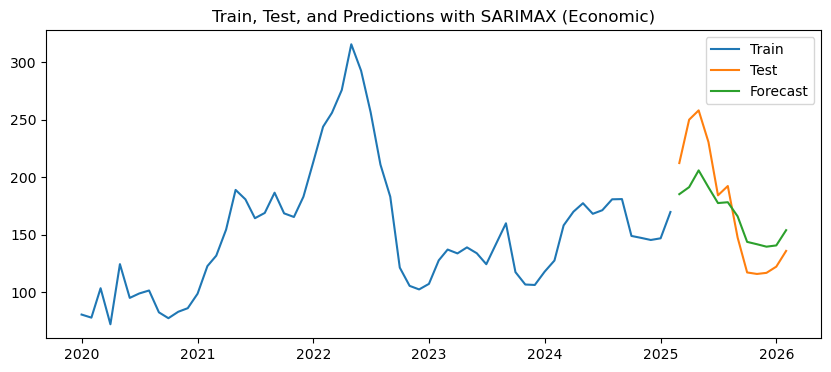

The MAE is 27.34
The RMSE is 31.06
The MAPE is  15.81%

FINAL MODEL COMPARISON:
             Model       MAE      RMSE    MAPE %
      Holt-Winters 32.303716 35.384311 20.148115
            SARIMA 28.510910 34.563296 15.334952
SARIMAX (Economic) 27.338186 31.059066 15.812973

✓ Best Model: SARIMA


In [34]:
## Train SARIMAX with Exogenous Variables

# Fit SARIMAX with economic data
model_sarimax_improved = SARIMAX(train,
                                exog=exog_train_new,
                                order=(2, 0, 0),       
                                seasonal_order=(1, 0, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)

# Fit and make predictions
result_sarimax_improved = model_sarimax_improved.fit(disp=False)
print("SARIMAX with Economic Data - Model Summary:")
print(result_sarimax_improved.summary())    
# Make predictions
predictions_sarimax_improved = result_sarimax_improved.get_forecast(
    steps=len(test),
    exog=exog_test_new
).predicted_mean        

# Assess
print("\n" + "="*60)
print("SARIMAX with Economic Variables:")
model_assessment(train['2020':], test, predictions_sarimax_improved, 'SARIMAX (Economic)')

# Final Comparison
print("\n" + "="*60)
print("FINAL MODEL COMPARISON:")
print("="*60)

mae_triple = mean_absolute_error(test, predictions_triple)
rmse_triple = mean_squared_error(test, predictions_triple)**0.5
mape_triple = mean_absolute_percentage_error(test, predictions_triple)

mae_sarima = mean_absolute_error(test, predictions_sarima)
rmse_sarima = mean_squared_error(test, predictions_sarima)**0.5
mape_sarima = mean_absolute_percentage_error(test, predictions_sarima)

mae_sarimax_new = mean_absolute_error(test, predictions_sarimax_improved)
rmse_sarimax_new = mean_squared_error(test, predictions_sarimax_improved)**0.5
mape_sarimax_new = mean_absolute_percentage_error(test, predictions_sarimax_improved)

comparison = pd.DataFrame({
    'Model': ['Holt-Winters', 'SARIMA', 'SARIMAX (Economic)'],
    'MAE': [mae_triple, mae_sarima, mae_sarimax_new],
    'RMSE': [rmse_triple, rmse_sarima, rmse_sarimax_new],
    'MAPE %': [100*mape_triple, 100*mape_sarima, 100*mape_sarimax_new]
})

print(comparison.to_string(index=False))
print("\n✓ Best Model: " + comparison.loc[comparison['MAPE %'].idxmin(), 'Model'])


## 12-Month Forecast (SARIMAX with Economic Data)

c:\Users\LUJEN\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


12-MONTH FORECAST TIMELINE
 Month #          Month       Date  Forecast (¢/lb)
       1     March 2026 2026-03-01           151.81
       2     April 2026 2026-04-01           165.55
       3       May 2026 2026-05-01           183.16
       4      June 2026 2026-06-01           177.51
       5      July 2026 2026-07-01           169.72
       6    August 2026 2026-08-01           171.22
       7 September 2026 2026-09-01           165.77
       8   October 2026 2026-10-01           146.28
       9  November 2026 2026-11-01           137.35
      10  December 2026 2026-12-01           140.81
      11   January 2027 2027-01-01           150.93
      12  February 2027 2027-02-01           160.92


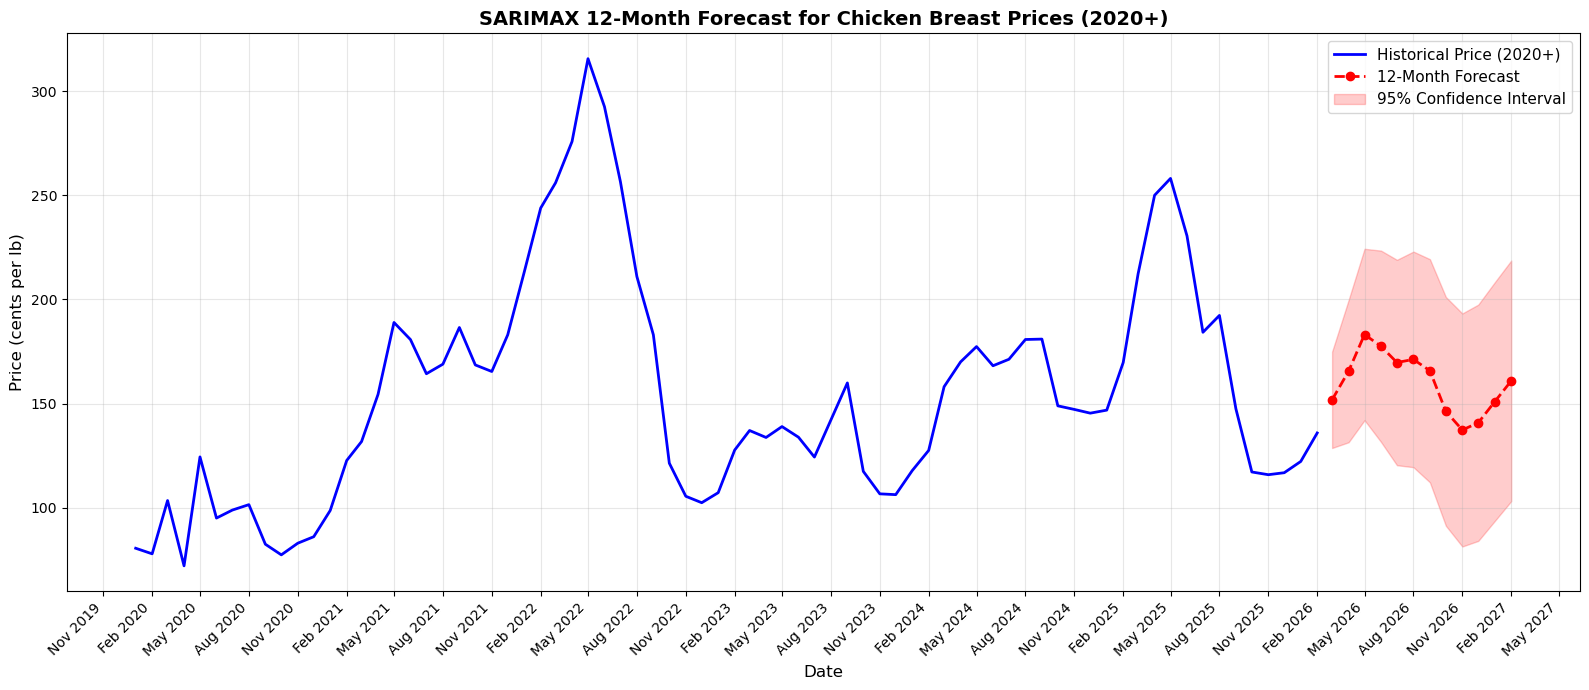


FORECAST STATISTICS
Mean forecast price:    $160.09 cents/lb
Min forecast price:     $137.35 cents/lb  (November 2026)
Max forecast price:     $183.16 cents/lb  (May 2026)
Price range:            $45.82 cents/lb

Current price (last observation):  $135.91 cents/lb (February 2026)
Expected price change: $+24.18 cents/lb (+17.8%)

Forecast range: March 2026 to February 2027


In [35]:
# Combine train and test data for full model refit
full_y = pd.concat([train, test])
full_X = pd.concat([exog_train_new, exog_test_new])

# Refit model on full dataset
model_full = SARIMAX(
    full_y,
    exog=full_X,
    order=(2, 0, 0),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_full = model_full.fit(disp=False)

# Create future dates for 12-month forecast
future_periods = 12
last_date = full_y.index[-1]
future_index = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=future_periods,
    freq='MS'
)

# Create future exogenous variables (use last known values repeated)
last_exog_row = full_X.iloc[[-1]]
future_exog = pd.DataFrame(
    np.repeat(last_exog_row.values, future_periods, axis=0),
    index=future_index,
    columns=full_X.columns
)

# Generate 12-month forecast
forecast_12m = result_full.forecast(
    steps=future_periods,
    exog=future_exog
)

forecast_12m = pd.Series(forecast_12m, index=future_index)

print("="*60)
print("12-MONTH FORECAST TIMELINE")
print("="*60)

# Format the forecast with clearer month/year display
forecast_display = pd.DataFrame({
    'Month #': range(1, 13),
    'Month': [d.strftime('%B %Y') for d in forecast_12m.index],
    'Date': forecast_12m.index.strftime('%Y-%m-%d'),
    'Forecast (¢/lb)': forecast_12m.values.round(2)
})
print(forecast_display.to_string(index=False))

# Calculate confidence interval
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
forecast_result = result_full.get_forecast(
    steps=future_periods,
    exog=future_exog
)
forecast_ci = forecast_result.conf_int()

# Visualization - focus from 2020 onwards
fig, ax = plt.subplots(figsize=(16, 7))

# Plot historical data from 2020 onwards
hist_data_2020 = full_y['2020':]
ax.plot(hist_data_2020.index, hist_data_2020.values, 'b-', label='Historical Price (2020+)', linewidth=2)

# Plot forecast
ax.plot(forecast_12m.index, forecast_12m.values, 'r--', label='12-Month Forecast', linewidth=2, marker='o', markersize=6)

# Plot confidence interval
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='red',
    alpha=0.2,
    label='95% Confidence Interval'
)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (cents per lb)', fontsize=12)
ax.set_title('SARIMAX 12-Month Forecast for Chicken Breast Prices (2020+)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Format x-axis to show dates more clearly
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Summary statistics for forecast
print("\n" + "="*60)
print("FORECAST STATISTICS")
print("="*60)
print(f"Mean forecast price:    ${forecast_12m.mean():.2f} cents/lb")
print(f"Min forecast price:     ${forecast_12m.min():.2f} cents/lb  ({forecast_12m.idxmin().strftime('%B %Y')})")
print(f"Max forecast price:     ${forecast_12m.max():.2f} cents/lb  ({forecast_12m.idxmax().strftime('%B %Y')})")
print(f"Price range:            ${forecast_12m.max() - forecast_12m.min():.2f} cents/lb")
print(f"\nCurrent price (last observation):  ${full_y.iloc[-1]:.2f} cents/lb ({full_y.index[-1].strftime('%B %Y')})")
print(f"Expected price change: ${forecast_12m.mean() - full_y.iloc[-1]:+.2f} cents/lb ({(forecast_12m.mean() - full_y.iloc[-1])/full_y.iloc[-1]*100:+.1f}%)")
print(f"\nForecast range: {forecast_12m.index[0].strftime('%B %Y')} to {forecast_12m.index[-1].strftime('%B %Y')}")


In [36]:
# Export forecast table to CSV and display detailed version
forecast_export = pd.DataFrame({
    'Month': range(1, 13),
    'Date': forecast_12m.index.strftime('%Y-%m-%d'),
    'Month Name': forecast_12m.index.strftime('%B %Y'),
    'Forecast Price (¢/lb)': forecast_12m.values.round(2),
    'CI Lower (¢/lb)': forecast_ci.iloc[:, 0].values.round(2),
    'CI Upper (¢/lb)': forecast_ci.iloc[:, 1].values.round(2)
})

print("\n" + "="*100)
print("DETAILED 12-MONTH FORECAST TABLE")
print("="*100)
print(forecast_export.to_string(index=False))

# Export to CSV
forecast_export.to_csv('forecast_12months.csv', index=False)
print("\n✓ Forecast exported to: forecast_12months.csv")

# Summary by quarter
print("\n" + "="*100)
print("QUARTERLY SUMMARY")
print("="*100)
quarterly_summary = pd.DataFrame({
    'Quarter': ['Q3 2026 (Jun-Aug)', 'Q4 2026 (Sep-Nov)', 'Q1 2027 (Dec-Feb)', 'Q2 2027 (Mar-May)'],
    'Avg Price (¢/lb)': [
        forecast_12m.iloc[0:3].mean(),
        forecast_12m.iloc[3:6].mean(),
        forecast_12m.iloc[6:9].mean(),
        forecast_12m.iloc[9:12].mean()
    ],
    'Min Price (¢/lb)': [
        forecast_12m.iloc[0:3].min(),
        forecast_12m.iloc[3:6].min(),
        forecast_12m.iloc[6:9].min(),
        forecast_12m.iloc[9:12].min()
    ],
    'Max Price (¢/lb)': [
        forecast_12m.iloc[0:3].max(),
        forecast_12m.iloc[3:6].max(),
        forecast_12m.iloc[6:9].max(),
        forecast_12m.iloc[9:12].max()
    ]
}).round(2)
print(quarterly_summary.to_string(index=False))
quarterly_summary.to_csv('forecast_quarterly_summary.csv', index=False)
print("\n✓ Quarterly summary exported to: forecast_quarterly_summary.csv")



DETAILED 12-MONTH FORECAST TABLE
 Month       Date     Month Name  Forecast Price (¢/lb)  CI Lower (¢/lb)  CI Upper (¢/lb)
     1 2026-03-01     March 2026                 151.81           128.70           174.93
     2 2026-04-01     April 2026                 165.55           131.45           199.66
     3 2026-05-01       May 2026                 183.16           142.02           224.30
     4 2026-06-01      June 2026                 177.51           131.60           223.42
     5 2026-07-01      July 2026                 169.72           120.44           219.01
     6 2026-08-01    August 2026                 171.22           119.49           222.96
     7 2026-09-01 September 2026                 165.77           112.22           219.31
     8 2026-10-01   October 2026                 146.28            91.38           201.18
     9 2026-11-01  November 2026                 137.35            81.42           193.27
    10 2026-12-01  December 2026                 140.81           

## Substitute Bird Flu Data with Slaughtered Data
Source: https://quickstats.nass.usda.gov/

Filters used: 
- Program: Survey
- Sector: Animals & Products 
- Group: Poultry
- Commodity: Chicken
- Category: Slaughtered
- Data Item: Pulled Individually: CHICKENS, YOUNG, SLAUGHTER, FI - SLAUGHTERED, MEASURED IN HEAD; CHICKENS, YOUNG, SLAUGHTER, FI - SLAUGHTERED, MEASURED IN LB/HEAD, LIVE BASIS; 
CHICKENS, YOUNG, SLAUGHTER, FI - SLAUGHTERED, MEASURED IN LBS, LIVE BASIS.
- Geographic level: National
- Year: 2000 - 2026
- Period type: Monthly

## Bring in inventory (later)
Inventory acts as a buffer or supply shock absorber
- If high slaughter, high inventory -> price drops
- If high slaughter, low inventory -> price may stay stable
- If low slaughter (supply shock), low inventory -> price spikes

In [37]:
# Read three slaughter datasets
slaughter_head = pd.read_csv('slaughtered_head_count.csv')
slaughter_total_lbs = pd.read_csv('slaughtered_total_lbs.csv')
slaughter_svg_lbs = pd.read_csv('slaughtered_avg_lbs_per_head.csv')

In [38]:
slaughter_head.head()

,Program,Year,Period,Week Ending,Geo Level,State,State ANSI,Ag District,Ag District Code,County,...,Zip Code,Region,watershed_code,Watershed,Commodity,Data Item,Domain,Domain Category,Value,CV (%)
0,SURVEY,2026,FEB,NaN,NATIONAL,US TOTAL,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CHICKENS,"CHICKENS, YOUNG, SLAUGHTER, FI - SLAUGHTERED, ...",TOTAL,NOT SPECIFIED,"754,189,000",NaN
1,SURVEY,2026,JAN,NaN,NATIONAL,US TOTAL,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CHICKENS,"CHICKENS, YOUNG, SLAUGHTER, FI - SLAUGHTERED, ...",TOTAL,NOT SPECIFIED,"801,189,000",NaN
2,SURVEY,2026,MAR,NaN,NATIONAL,US TOTAL,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CHICKENS,"CHICKENS, YOUNG, SLAUGHTER, FI - SLAUGHTERED, ...",TOTAL,NOT SPECIFIED,"830,562,000",NaN
3,SURVEY,2025,APR,NaN,NATIONAL,US TOTAL,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CHICKENS,"CHICKENS, YOUNG, SLAUGHTER, FI - SLAUGHTERED, ...",TOTAL,NOT SPECIFIED,"796,496,000",NaN
4,SURVEY,2025,AUG,NaN,NATIONAL,US TOTAL,NaN,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CHICKENS,"CHICKENS, YOUNG, SLAUGHTER, FI - SLAUGHTERED, ...",TOTAL,NOT SPECIFIED,"797,046,000",NaN


In [39]:
# Function to load and clean slaughter data
def load_slaughter_file(path, item_contains=None):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(
        df['Year'].astype(str) + '-' + df['Period'].str.title(),
        format='%Y-%b'
    )
    if item_contains:
        df = df[df['Data Item'].str.contains(item_contains, case=False, na=False)]
    df['Value'] = (
        df['Value'].astype(str)
             .str.replace(',', '')
             .astype(float)
    )
    return df[['date', 'Data Item', 'Value']]

In [40]:
# Load each slaughter dataset with appropriate filtering
head = load_slaughter_file('slaughtered_head_count.csv', item_contains='MEASURED IN HEAD')
total_lbs = load_slaughter_file('slaughtered_total_lbs.csv', item_contains='MEASURED IN LB, LIVE BASIS')
avg_lbs = load_slaughter_file('slaughtered_avg_lbs_per_head.csv', item_contains='MEASURED IN LB / HEAD')

In [41]:
# Aggregate by date to get total head count, total lbs, and average lbs per head for each month to align with the chicken price data
head = head.groupby('date')['Value'].sum().rename('head_count')
total_lbs = total_lbs.groupby('date')['Value'].sum().rename('total_lbs')
avg_lbs = avg_lbs.groupby('date')['Value'].sum().rename('avg_lbs_per_head')

exog = pd.concat([head, total_lbs, avg_lbs], axis=1).reset_index()

In [42]:
# Merge with drivers dataset on date
drivers['head_count'] = head
drivers['total_lbs'] = total_lbs
drivers['avg_lbs_per_head'] = avg_lbs

print("Updated drivers dataset shape:", drivers.shape)
print("\nDrivers columns:", drivers.columns.tolist())

Updated drivers dataset shape: (302, 6)

Drivers columns: ['breast', 'leg_quarters', 'wings', 'head_count', 'total_lbs', 'avg_lbs_per_head']


C:\Users\LUJEN\AppData\Local\Temp\ipykernel_3384\2408231624.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drivers['head_count'] = head
C:\Users\LUJEN\AppData\Local\Temp\ipykernel_3384\2408231624.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drivers['total_lbs'] = total_lbs
C:\Users\LUJEN\AppData\Local\Temp\ipykernel_3384\2408231624.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

In [43]:
drivers.head()

,breast,leg_quarters,wings,head_count,total_lbs,avg_lbs_per_head
date,,,,,,
2001-01-01,126.3,20.1,89.60,710683000.0,3.571736e+09,5.03
2001-02-01,130.2,20.3,85.40,627380000.0,3.145972e+09,5.01
2001-03-01,130.3,22.0,93.20,700816000.0,3.515792e+09,5.02
2001-04-01,125.6,26.4,96.00,675819000.0,3.411201e+09,5.05
2001-05-01,126.6,28.3,102.88,755640000.0,3.832893e+09,5.07


## EDA on Supply data (total_lbs)
Used total_lbs out of three becuase it directly represents supply volume, which is the most economically relevant driver of price

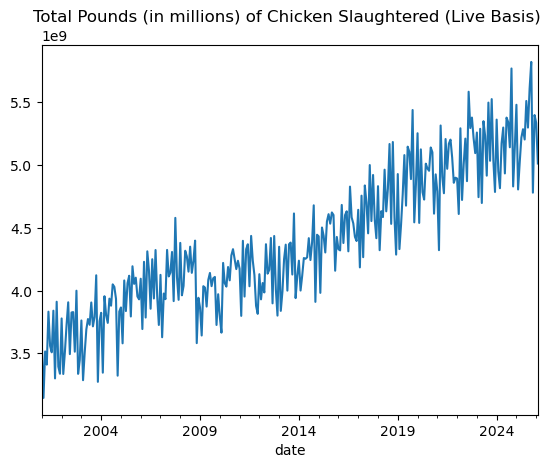

In [44]:
# Plot the total lbs driver
drivers['total_lbs'].plot(title='Total Pounds (in millions) of Chicken Slaughtered (Live Basis) ')
plt.show()

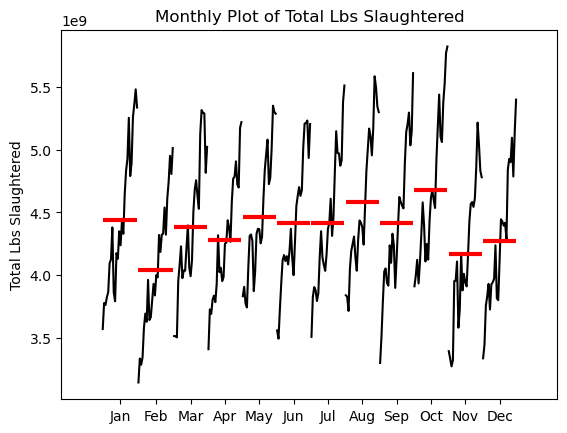

In [45]:
# Monthly plot
month_plot(drivers['total_lbs'], ylabel='Total Lbs Slaughtered')
plt.title('Monthly Plot of Total Lbs Slaughtered')
plt.show()
# Observation: Seasonal monthly drop in February, November, and December
# Peaks in October.

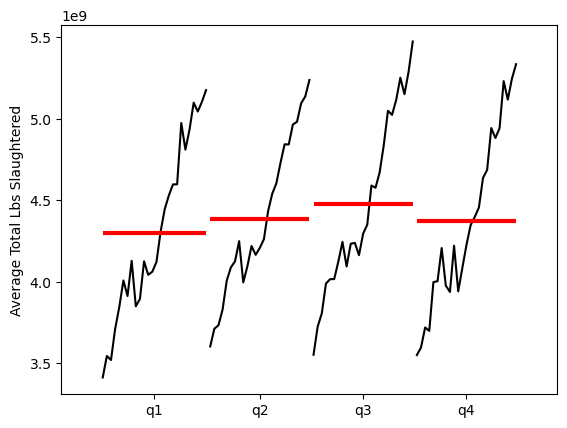

In [46]:
# Quarterly plot 
quarter_plot(drivers['total_lbs'].resample('QS').mean(), ylabel='Average Total Lbs Slaughtered')
plt.show()

## SARIMAX using total_lbs as exogenous variables

In [47]:
# Train test split 
period = 12
train = drivers.iloc[:-period, 0]
test = drivers.iloc[-period:, 0]
exog_train = drivers.iloc[:-period, 3:]  # Exogenous variables for training
exog_test = drivers.iloc[-period:, 3:]   # Exogenous variables for testing

In [48]:
# Find the best SARIMA parameters bsed on AIC
model_sarima = auto_arima(train,
                          seasonal = True, 
                          m = 12, 
                          stepwise = True, 
                          trace = True)
print(model_sarima.summary())
model_sarima.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2887.768, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2322.259, Time=0.31 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2592.011, Time=0.18 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3681.931, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=2356.852, Time=0.04 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=2309.377, Time=1.01 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.23 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.55 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=2867.490, Time=1.31 sec
 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=2288.535, Time=2.04 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=2297.015, Time=0.62 sec
 ARIMA(2,0,0)(2,0,1)[12] intercept   : AIC=2270.693, Time=1.76 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=2265.305, Time=0.75 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  290
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 12)   Log Likelihood               -1126.652
Date:                              Wed, 03 Jun 2026   AIC                           2265.305
Time:                                      15:52:07   BIC                           2287.324
Sample:                                  01-01-2001   HQIC                          2274.127
                                       - 02-01-2025                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1823      0.259      0.705      0.481      -0.325       0.689
ar.L1          1.1410      0.036     31.673      0.000       1.070       1.212
ar.L2         -0.2206      0.035     -6.285      0.000      -0.289      -0.152
ar.S.L12       0.9831      0.021     47.408      0.000       0.942       1.024
ma.S.L12      -0.8798      0.065    -13.466      0.000      -1.008      -0.752
sigma2       132.3433      8.935     14.812      0.000     114.831     149.855
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                83.99
Prob(Q):                              0.81   Prob(JB):                         0.00
Heteroskedasticity (H):               2.30   Skew:                            -0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [49]:
# Fit SARIMAX with economic data
model_sarimax_supply = SARIMAX(train,
                                exog=exog_train,
                                order=(2, 0, 0),       
                                seasonal_order=(1, 0, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)

In [50]:
# Make predictions
result_sarimax_supply = model_sarimax_supply.fit(disp=False)

c:\Users\LUJEN\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


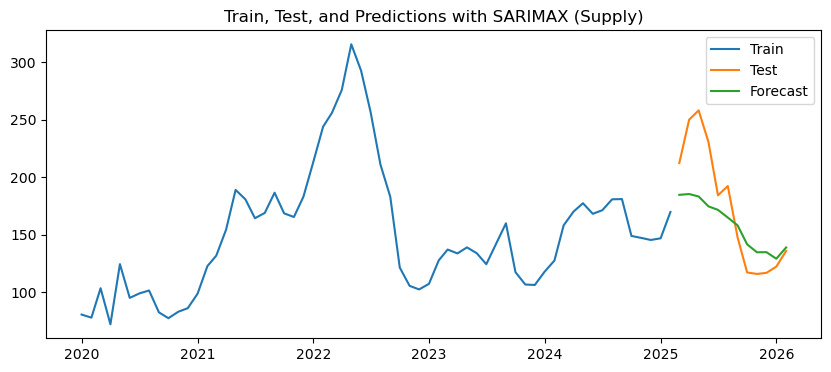

The MAE is 28.72
The RMSE is 36.53
The MAPE is  15.06%


In [51]:
# Fit the model and make predictions
predictions_sarimax_supply = result_sarimax_supply.predict(
    start=test.index[0], 
    end=test.index[-1], 
    exog=exog_test
)
model_assessment(train['2020':], test, predictions_sarimax_supply, 'SARIMAX (Supply)')

SARIMAX model using Supply And Economic Factors from FRED

In [52]:
# Merge data, drop consumer price index and unemployment rate to avoid multicollinearity, and add total lbs as a key driver
exog_full = exog_external_clean.copy()
exog_full['total_lbs'] = drivers['total_lbs']

data_aligned = drivers[['breast']].join(exog_full, how='inner').dropna() 

In [53]:
data_aligned.tail()

,breast,"Corn Prices (Global Price, USD/Metric Ton Monthly)",Soybean Prices (USD/Metric Ton Monthly),"Heating Oil Prices (Monthly, $/gallon)",Unemployment Rate,Consumer Sentiment Index,Consumer Price Index,Beef Price (US cents/lb Monthly),total_lbs
date,,,,,,,,,
2025-10-01,117.19,198.017644,371.574143,2.190,4.4,53.6,324.245,314.000000,5.822282e+09
2025-11-01,115.88,201.657888,410.169359,2.376,4.5,51.0,325.063,325.500000,4.780863e+09
2025-12-01,116.84,205.315080,391.549884,2.112,4.4,52.9,326.031,338.652174,5.399048e+09
2026-01-01,122.24,203.897824,383.241403,2.111,4.3,56.4,326.588,330.954545,5.336298e+09
2026-02-01,135.91,210.635487,409.479246,2.354,4.4,56.6,327.460,344.500000,5.013105e+09


In [54]:
y = data_aligned['breast']
X = data_aligned.drop(columns=['breast'])

In [55]:
period = 12

train_y = y.iloc[:-period]
test_y  = y.iloc[-period:]

train_X = X.iloc[:-period]
test_X  = X.iloc[-period:]

In [56]:
train_y

date
2001-01-01    126.30
2001-02-01    130.20
2001-03-01    130.30
2001-04-01    125.60
2001-05-01    126.60
               ...  
2024-10-01    148.93
2024-11-01    147.21
2024-12-01    145.42
2025-01-01    146.87
2025-02-01    169.75
Freq: MS, Name: breast, Length: 290, dtype: float64

In [57]:
test_y

date
2025-03-01    212.29
2025-04-01    249.98
2025-05-01    258.07
2025-06-01    230.48
2025-07-01    184.23
2025-08-01    192.32
2025-09-01    147.50
2025-10-01    117.19
2025-11-01    115.88
2025-12-01    116.84
2026-01-01    122.24
2026-02-01    135.91
Freq: MS, Name: breast, dtype: float64

In [58]:
scaler = StandardScaler()

train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled  = scaler.transform(test_X)

# Convert back to DataFrame
train_X_scaled = pd.DataFrame(train_X_scaled, index=train_X.index, columns=train_X.columns)
test_X_scaled  = pd.DataFrame(test_X_scaled, index=test_X.index, columns=test_X.columns)

In [59]:

auto_model = auto_arima(
    train_y,
    exogenous=train_X_scaled,
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

auto_model.summary()


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.77 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2887.768, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2322.259, Time=0.29 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2592.011, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3681.931, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=2356.852, Time=0.04 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=2309.377, Time=0.94 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.21 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.49 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=2867.490, Time=1.45 sec
 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=2288.535, Time=2.08 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=2297.015, Time=0.49 sec
 ARIMA(2,0,0)(2,0,1)[12] intercept   : AIC=2270.693, Time=1.52 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=2265.305, Time=0.60 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  290
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 12)   Log Likelihood               -1126.652
Date:                              Wed, 03 Jun 2026   AIC                           2265.305
Time:                                      15:52:25   BIC                           2287.324
Sample:                                  01-01-2001   HQIC                          2274.127
                                       - 02-01-2025                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1823      0.259      0.705      0.481      -0.325       0.689
ar.L1          1.1410      0.036     31.673      0.000       1.070       1.212
ar.L2         -0.2206      0.035     -6.285      0.000      -0.289      -0.152
ar.S.L12       0.9831      0.021     47.408      0.000       0.942       1.024
ma.S.L12      -0.8798      0.065    -13.466      0.000      -1.008      -0.752
sigma2       132.3433      8.935     14.812      0.000     114.831     149.855
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                83.99
Prob(Q):                              0.81   Prob(JB):                         0.00
Heteroskedasticity (H):               2.30   Skew:                            -0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [60]:

model = SARIMAX(
    train_y,
    exog=train_X_scaled,
    order=(2, 0, 0),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)

print(result.summary())


                                      SARIMAX Results                                       
Dep. Variable:                               breast   No. Observations:                  290
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 12)   Log Likelihood               -1071.656
Date:                              Wed, 03 Jun 2026   AIC                           2169.313
Time:                                      15:52:26   BIC                           2216.378
Sample:                                  01-01-2001   HQIC                          2188.199
                                       - 02-01-2025                                         
Covariance Type:                                opg                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Corn Prices (Globa

c:\Users\LUJEN\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [61]:
predictions = result.forecast(
    steps=len(test_y),
    exog=test_X_scaled
)

predictions = pd.Series(predictions, index=test_y.index)

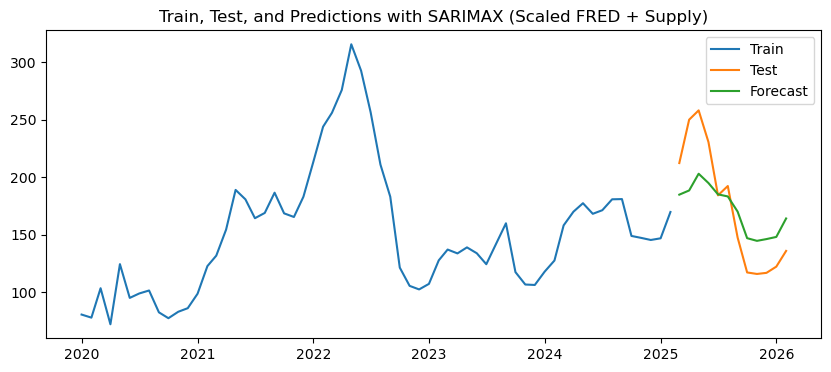

The MAE is 29.51
The RMSE is 33.51
The MAPE is  17.67%


In [62]:
model_assessment(train_y['2020':], test_y, predictions, 'SARIMAX (Scaled FRED + Supply)')
